# Presentation of results
Victor Camps, Saïd Tellez, Steven Yu

Because this project out reaches the class, we want to make sure our project is understandable outside of France.
Hence this project is in English,
A french version will be available if needed

In [ ]:
# TODO: make an french version of the README.md, the code etc --> we only need to change the text, 
# not the code


## Presentation

In this project, we wanted to create a modular program to compare stochastic models to ML models to forecast the (...) volatility of a stock of the S&P500.
At the beginning of this class, we wanted to work on vanilla options on those stocks, but due to the lack of data, we we're forced to change the point of the project.

## Introduction to financial terms

In finance, a **stock** represents a fraction of ownership in a company, and its price evolves randomly over time under the influence of market forces. \
The **stock return**, often defined as the logarithmic difference between consecutive prices, measures the relative gain or loss of the asset. \
The **volatility** of a stock corresponds to the variability of these returns: mathematically, it is the standard deviation (or conditional variance) of returns over a given horizon. High volatility means large fluctuations and thus higher uncertainty or risk. \
The **VIX index**, often called the “fear index”, is a market-implied measure of expected volatility derived from S&P 500 options; it reflects investors’ anticipation of future market turbulence. 


**Accurately forecasting volatility is essential in finance** because it **underpins risk management, derivative pricing, and portfolio allocation**, all of which rely on quantifying uncertainty. 


However, **predicting volatility presents specific mathematical and machine-learning challenges**. 
**Financial time series are non-stationary and autocorrelated**, meaning that past values strongly influence the present, so data cannot be randomly shuffled as in standard ML tasks without breaking the temporal structure. \
Evaluation metrics must also reflect the asymmetric cost of errors: underestimating volatility (and thus risk) is much more damaging than overestimating it. \
For this reason, **instead of the classical Mean Squared Error, we use the QLIKE (Quasi-Likelihood) loss**, a function derived from likelihood theory in econometrics, which penalizes under-predictions more heavily and aligns better with the probabilistic modeling of variance. This intersection of mathematics and finance thus illustrates how statistical modeling, optimization, and time-series analysis combine to understand and manage financial risk.

## Presentation of the project

We tried to make the project as professional as readable as possible. Thus, we detailed the structure of the project in the README.md, but we'll make a quick summary in here.

We wanted it to be modular, so we coded the models in the folder `src\volforecast\models`, in this notebook, you will only find calls to functions coded in thoses files, to make the presentation readable. \
As part of the same idea, the evaluation methods are written in the folder `src\volforecast\evaluation`. 

We used data from Yahoo finance, using the code in the folder `src\volforecast\data`, and the csv files created are stored in the folder `data`. 

The figures created are in the folder `reports`.

To call all of the models at once, with the parameters detailed in the file `configs\default.yaml`, you can run the script `scripts\run_all.py`. Careful, it can be veery long


We we're interested to use ML models to forecast volatility, because the stochastic model is quite basic, and doesn't include a lot of parameters. Eventhough it works quite well, we wanted to try to improve it.

We tried three levels of complexity of models in this project, to balance performance with efficiency and speed of computation, because trading desks need to have fast algorithms to be the first ones to have an information, but at the same time need reliable information, to make good decisions.


Before running any code, we need to make sure we have all the latest versions of the packages

In [13]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Presentation of each model

### Presentation of the GARCH Model

In [ ]:
## TODO: Steven présente le modèle GARCH

### Presentation of the Linear regression with Elasticnet CV


The first one is the simplest model, it is a linear regression with elasticnet cross validation. The objective of this one is to be computationnaly quick. We wanted to see if the vol forecast could be linear in a short period. We don't expect quality results

We have to import tha model

In [14]:
from volforecast.models.elasticnet_regression import ElasticNetRegression_config, ElasticNetRegression


In [8]:
#Loading data
csv_path = "../data/dataset_AAPL.csv"
df = pd.read_csv(csv_path, sep= ";", parse_dates=["Date"])
df = df.sort_values("Date")
df.head()


,Date,AAPL_Close,SP500_Close,VIX_Close,Open,High,Low,Close,Volume,log_return_AAPL,log_return_SP500,log_return_VIX
0,2010-01-05,6.435712,1136.520020,19.350000,6.442317,6.472037,6.401789,6.435712,601904800,0.001727,0.003111,-0.035038
1,2010-01-06,6.333344,1137.140015,19.160000,6.435713,6.461230,6.326739,6.333344,552160000,-0.016034,0.000545,-0.009868
2,2010-01-07,6.321635,1141.689941,19.059999,6.356759,6.364264,6.275705,6.321635,477131200,-0.001850,0.003993,-0.005233
3,2010-01-08,6.363666,1144.979980,18.129999,6.313232,6.364267,6.276008,6.363666,447610800,0.006627,0.002878,-0.050024
4,2010-01-11,6.307527,1146.979980,17.549999,6.388281,6.394285,6.257693,6.307527,462229600,-0.008861,0.001745,-0.032514


In [15]:
# Configure and train the model
cfg = ElasticNetRegression_config(
    date="Date",
    log_return_stock="log_return_AAPL",
    vix_close="VIX_Close",
    market_close="SP500_Close",
    log_return_SP500="log_return_SP500",
    log_return_VIX="log_return_VIX",
    target="next_squared_return_stock",    # next-day squared returns
    lags=[1,2,3,5,10,20],
    rolling_windows=[5,10,20],
    include_calendar_features=True,
    log_transform=True,
    n_splits=5
)
model = ElasticNetRegression(cfg)
model.fit(df)
metrics_in = model.evaluate(df)
metrics_in


c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.015e+00, tolerance: 7.051e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.968e+01, tolerance: 7.051e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. Yo

{'RMSE': 0.0008363833301357029,
 'MAE': 0.0002798805141230375,
 'QLIKE': -5.534514043705056,
 'best_alpha': 0.057904439806024895,
 'best_l1_ratio': 0.9,
 'n_features': 47,
 'coefficients': {'log_return_VIX': 0.042368453853339705,
  'lag_returns_1': -0.06105944642012142,
  'lag_volatility_1': 0.0,
  'lag_vix_1': 0.35462110917089384,
  'lag_log_return_vix_1': 0.0,
  'lag_market_close_1': 0.0,
  'lag_market_return_1': -0.0,
  'lag_returns_2': -0.0,
  'lag_volatility_2': 0.0,
  'lag_vix_2': 0.0,
  'lag_log_return_vix_2': 0.0,
  'lag_market_close_2': 0.0,
  'lag_market_return_2': -0.0,
  'lag_returns_3': -0.006619894905039471,
  'lag_volatility_3': 0.0,
  'lag_vix_3': 0.0,
  'lag_log_return_vix_3': 0.0,
  'lag_market_close_3': 0.0,
  'lag_market_return_3': -0.0,
  'lag_returns_5': -0.0,
  'lag_volatility_5': 0.0,
  'lag_vix_5': 0.0,
  'lag_log_return_vix_5': 0.0,
  'lag_market_close_5': 0.0,
  'lag_market_return_5': -0.048165799007879644,
  'lag_returns_10': -0.012435813294921468,
  'lag_vo

In [16]:
# Holdout evaluation: last 252 business days as test
metrics_test = model.fit_on_train_predict_on_test(df, n_test=252)
metrics_test


c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.824e+01, tolerance: 4.289e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.687e+02, tolerance: 4.289e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\vicca\Desktop\Centrale\EI3\STASC\project_camps_tellez_yuu\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. Yo

{'RMSE': 0.022565020551883058,
 'MAE': 0.00020292285754660647,
 'QLIKE': 202922829.9195536,
 'best_alpha': 0.2982471286216894,
 'best_l1_ratio': 0.1,
 'n_features': 47}

We can see that the model uses a lot more of L2 loss than L1 loss, so there's not a big selection of features, all are used basically
The best alpha is quite low, we don't penalize a lot --> maybe that's why QLIKE loss is that high ?

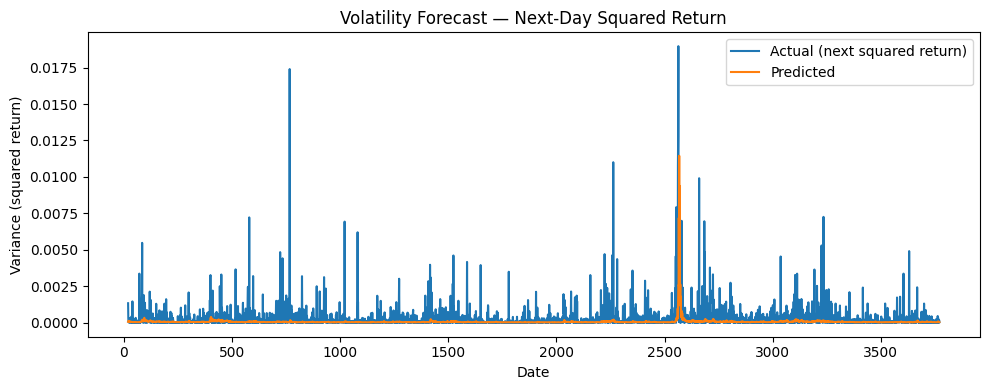

In [17]:
# Predictions (aligned with the internally built feature index)
y_pred = model.predict(df)

# Rebuild raw target to compare on same index
# raw target (no log transform) for plotting
target_raw = (df["log_return_AAPL"]**2).shift(-1)
target_raw = target_raw.loc[y_pred.index]

# Plot actual vs predicted (single chart, no custom colors)
plt.figure(figsize=(10,4))
plt.plot(target_raw.index, target_raw.values, label="Actual (next squared return)")
plt.plot(y_pred.index, y_pred.values, label="Predicted")
plt.legend()
plt.title("Volatility Forecast — Next-Day Squared Return")
plt.xlabel("Date")
plt.ylabel("Variance (squared return)")
plt.tight_layout()
plt.show()


In [18]:
# Inspect top coefficients kept by ElasticNet
enet = model.pipeline.named_steps["elasticnet"]
coefs = dict(zip(model.features, enet.coef_.tolist()))
# Show the largest positive and negative contributors
top_pos = sorted(coefs.items(), key=lambda kv: kv[1], reverse=True)[:10]
top_neg = sorted(coefs.items(), key=lambda kv: kv[1])[:10]
print("Top + coefficients:")
for k,v in top_pos:
    print(f"{k:30s} {v: .6f}")
print("\nTop - coefficients:")
for k,v in top_neg:
    print(f"{k:30s} {v: .6f}")


Top + coefficients:
lag_vix_1                       0.132528
lag_vix_2                       0.093477
lag_vix_3                       0.055897
lag_vix_5                       0.050350
log_return_VIX                  0.048268
lag_log_return_vix_1            0.046257
rolling_volatility_mean_10      0.043162
rolling_volatility_std_10       0.033634
lag_log_return_vix_2            0.024296
rolling_volatility_mean_20      0.021689

Top - coefficients:
lag_returns_1                  -0.063267
lag_market_return_5            -0.047932
lag_market_return_1            -0.026471
lag_returns_5                  -0.022594
lag_returns_20                 -0.020393
lag_returns_3                  -0.018835
lag_returns_2                  -0.017916
day_Wednesday                  -0.013954
day_Tuesday                    -0.012459
lag_returns_10                 -0.011224


We could expect this as the linear model is too simple to forecast the volatility.
What we can learn abt this is that the RMSE and the MAE are quite small, because the forecast is correct or close to correct a lot of times, but the QLIKE loss is very high, since it penalizes a lot underpredictions. Hence, this model is not usable in that way.

TODO: Add conclusions abt what coefficients are the most important and the less important

### Presentation of the LSTM Model

In [ ]:
# TODO: Saïd c'est ton truc à faire ici